# CatDogClassifier - EfficientNetB0 - Top 5 Light, rank 1

Based on `CatDogClassifier TransferLearningV2DataAugmentationBase.ipynb`.
Train the classification head, then fine-tune the backbone. Evaluate, plot and save each phase separately.
Use the project's `env.yml` or Docker environment and run cells in order.

ImageNet reference: 77.1% Top-1 accuracy.
Source: [Keras Applications](https://keras.io/api/applications/) and
[MobileNet models](https://keras.io/api/applications/mobilenet/mobilenet_models/).
This is a selection reference, not a cats/dogs result. Light classifiers have at most
5 million total parameters after replacing the ImageNet head. Adjust `BATCH_SIZE`
to available memory and restart the kernel between large models.


In [1]:
from pathlib import Path

ARCHITECTURE = 'EfficientNetB0'
GROUP = 'Light'
RANK_IMAGENET = 1
IMAGENET_TOP1 = 77.1
IMAGENET_PARAMETERS_M = 5.3
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
VALIDATION_SPLIT = 0.1
TRANSFER_EPOCHS = 100
FINETUNE_EPOCHS = 50
FINE_TUNE_LAST_N = 20
THRESHOLD = 0.5
PRETRAINED_WEIGHTS = "imagenet"
EXPORT_TFLITE = False  # Enable mobile export if needed.

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "content").is_dir():
    raise FileNotFoundError("Open the notebook from the cat_dogs project root.")
train_data_dir = PROJECT_ROOT / "content/cats-and-dogs-for-classification/cats_dogs/train_crop075"
test_data_dir = PROJECT_ROOT / "content/cats-and-dogs-for-classification/cats_dogs/test"
RUN_NAME = f"cat_dog_{ARCHITECTURE}_Top5{GROUP}"
MODEL_DIR = PROJECT_ROOT / "models" / "top10" / RUN_NAME
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "top10" / RUN_NAME
RESULT_DIR = PROJECT_ROOT / "out" / "top10" / RUN_NAME
TRANSFER_MODEL_PATH = MODEL_DIR / f"{RUN_NAME}_transfer_learning.keras"
TRANSFER_WEIGHTS_PATH = MODEL_DIR / f"{RUN_NAME}_transfer_learning.weights.h5"
FINETUNE_MODEL_PATH = MODEL_DIR / f"{RUN_NAME}_fine_tuning.keras"
FINETUNE_WEIGHTS_PATH = MODEL_DIR / f"{RUN_NAME}_fine_tuning.weights.h5"
MODEL_PATH = FINETUNE_MODEL_PATH  # Default for the inference example.
WEIGHTS_PATH = FINETUNE_WEIGHTS_PATH
TFLITE_PATH = MODEL_DIR / f"{RUN_NAME}_fine_tuning.tflite"
OPTIMIZED_TFLITE_PATH = MODEL_DIR / f"{RUN_NAME}_fine_tuning_optimized.tflite"
TRANSFER_CHECKPOINT = CHECKPOINT_DIR / "transfer.weights.h5"
FINETUNE_CHECKPOINT = CHECKPOINT_DIR / "finetune.weights.h5"


In [18]:
EXPORT_TFLITE = True

In [2]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass  # The device may already be initialized.
for directory in (MODEL_DIR, CHECKPOINT_DIR, RESULT_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print("TensorFlow:", tf.__version__)
print("Model:", ARCHITECTURE, "| batch:", BATCH_SIZE)


I0000 00:00:1789824076.588945    2218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789824077.998054    2218 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
Model: EfficientNetB0 | batch: 32


W0000 00:00:1789824078.675037    2218 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## Load data

Reserve 10% of `train_crop075` for validation with the same seed in both loaders.
Use the same validation data during transfer learning and fine-tuning.
The separate `test` directory is used to evaluate both saved phases.
Class labels follow the folder order.


In [3]:
train_data = tf.keras.utils.image_dataset_from_directory(
    str(train_data_dir), label_mode="binary", batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE, seed=SEED, shuffle=True,
    validation_split=VALIDATION_SPLIT, subset="training")
validation_data = tf.keras.utils.image_dataset_from_directory(
    str(train_data_dir), label_mode="binary", batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE, seed=SEED, shuffle=True,
    validation_split=VALIDATION_SPLIT, subset="validation")
class_names = list(train_data.class_names)
if len(class_names) != 2:
    raise ValueError(f"Expected two classes, found: {class_names}")
test_data = tf.keras.utils.image_dataset_from_directory(
    str(test_data_dir), label_mode="binary", class_names=class_names,
    batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, shuffle=False)
print("Classes:", dict(enumerate(class_names)))
print("Training images:", len(train_data.file_paths))
print("Validation images:", len(validation_data.file_paths))
print("Test images:", len(test_data.file_paths))


Found 7050 files belonging to 2 classes.
Using 6345 files for training.


W0000 00:00:1789824085.283271    2218 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


Found 7050 files belonging to 2 classes.
Using 705 files for validation.
Found 2000 files belonging to 2 classes.
Classes: {0: 'cats', 1: 'dogs'}
Training images: 6345
Validation images: 705
Test images: 2000


Images: (32, 224, 224, 3) Labels: (32, 1)


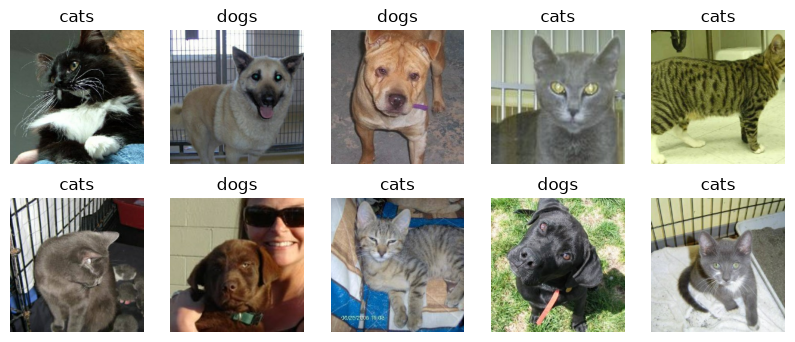

In [4]:
images, labels = next(iter(train_data))
print("Images:", images.shape, "Labels:", labels.shape)
plt.figure(figsize=(10, 4))
for i in range(min(10, int(images.shape[0]))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[int(labels[i, 0])])
    plt.axis("off")
plt.show()


## Data augmentation

Apply horizontal flips and zoom during training. Images use RGB [0, 255].


In [5]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomZoom(height_factor=(-0.15, 0.50),
                               fill_mode="constant", fill_value=255.0, seed=SEED + 1),
], name="data_augmentation")


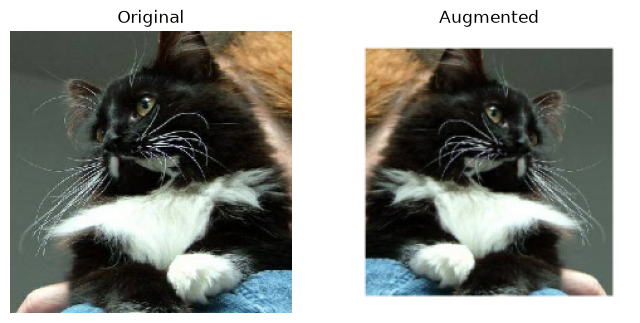

In [6]:
image = images[0]
augmented_image = data_augmentation(tf.expand_dims(image, 0), training=True)[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, value, title in zip(axes, [image, augmented_image], ["Original", "Augmented"]):
    ax.imshow(tf.cast(tf.clip_by_value(value, 0, 255), tf.uint8))
    ax.set_title(title)
    ax.axis("off")
plt.show()


## Transfer learning

Freeze the pretrained backbone and train a binary classification head.
Preprocessing is included in the model, which accepts RGB [0, 255].
The sigmoid output is the probability of `class_names[1]`.


In [7]:
pretrained_model = tf.keras.applications.EfficientNetB0(
    input_shape=(*IMAGE_SIZE, 3), include_top=False,
    weights=PRETRAINED_WEIGHTS)
pretrained_model.trainable = False


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3), name="rgb_image")
x = data_augmentation(inputs)
# The backbone includes preprocessing for RGB [0, 255].
x = pretrained_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_pool")(x)
x = tf.keras.layers.Dropout(0.2, seed=SEED, name="head_dropout")(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="prediction")(x)
model = tf.keras.Model(inputs, outputs, name=RUN_NAME)
total_parameters = model.count_params()
if GROUP == "Light" and total_parameters > 5_000_000:
    raise ValueError(f"The classifier exceeds 5 M parameters: {total_parameters:,}")
print(f"Total parameters: {total_parameters:,}")
model.summary()


Total parameters: 4,050,852


Model: "cat_dog_EfficientNetB0_Top5Light"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_image (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [9]:
def compile_model(learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=THRESHOLD),
                 tf.keras.metrics.Precision(name="precision", thresholds=THRESHOLD),
                 tf.keras.metrics.Recall(name="recall", thresholds=THRESHOLD),
                 tf.keras.metrics.AUC(name="auc", curve="ROC"),
                 tf.keras.metrics.F1Score(name="f1_score", average="micro", threshold=THRESHOLD)])

def make_callbacks(checkpoint, patience):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                          restore_best_weights=True, mode="min"),
        tf.keras.callbacks.ModelCheckpoint(str(checkpoint), monitor="val_loss",
                                            save_best_only=True, save_weights_only=True,
                                            mode="min"),
        tf.keras.callbacks.CSVLogger(str(RESULT_DIR / f"{checkpoint.stem}.csv")),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

compile_model(1e-3)


## Evaluate and save each phase

Save separate models and weights, training curves, test metrics and confusion matrices.
Both phases use the same test images and threshold. Precision and recall refer to
`class_names[1]`; the per-class report covers both classes. No phase is selected automatically.

`auc` uses ROC-AUC on sigmoid probabilities. `f1_score` uses the explicit
classification threshold (0.5 by default). With a single sigmoid output and
`average="micro"`, it measures F1 for the positive class, `class_names[1]`.
The separate `macro_f1` averages the F1 values of both classes.
Both new metrics are recorded during training, validation and test evaluation.
See [Keras classification metrics](https://keras.io/api/metrics/classification_metrics/).


In [10]:
def plot_history(history, stage, directory):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), layout="constrained")
    for ax, metric in zip(axes.flat, ["accuracy", "precision", "recall", "auc", "f1_score", "loss"]):
        epochs = range(1, len(history.history[metric]) + 1)
        ax.plot(epochs, history.history[metric], label="Training")
        ax.plot(epochs, history.history[f"val_{metric}"], label="Validation")
        ax.legend()
        ax.set(title=metric, xlabel="Epoch")
        ax.grid(alpha=0.3)
    fig.suptitle(stage.replace("_", " ").title() + " - training and validation")
    fig.savefig(directory / "training_history.png", dpi=150)
    plt.show()


def evaluate_and_save_stage(stage, history, minutes, model_path, weights_path):
    directory = RESULT_DIR / stage
    directory.mkdir(parents=True, exist_ok=True)
    # Save this phase before the next training phase changes the model weights.
    model.save(model_path)
    model.save_weights(weights_path)
    (MODEL_DIR / "labels.json").write_text(json.dumps(class_names, indent=2), encoding="utf-8")
    print("Saved model:", model_path)
    pd.DataFrame(history.history).to_csv(directory / "history.csv", index_label="epoch_index")
    plot_history(history, stage, directory)

    # Fresh metric instances prevent values from carrying over between phases.
    metrics = {
        "loss": tf.keras.metrics.BinaryCrossentropy(),
        "accuracy": tf.keras.metrics.BinaryAccuracy(threshold=THRESHOLD),
        "precision": tf.keras.metrics.Precision(thresholds=THRESHOLD),
        "recall": tf.keras.metrics.Recall(thresholds=THRESHOLD),
        "auc": tf.keras.metrics.AUC(name="auc", curve="ROC"),
        "f1_score": tf.keras.metrics.F1Score(name="f1_score", average="micro", threshold=THRESHOLD),
    }
    labels_all, probabilities_all = [], []
    for batch_images, batch_labels in test_data:
        probabilities = model(batch_images, training=False)
        for metric in metrics.values():
            metric.update_state(batch_labels, probabilities)
        labels_all.append(batch_labels.numpy().reshape(-1).astype(int))
        probabilities_all.append(probabilities.numpy().reshape(-1))
    y_true = np.concatenate(labels_all)
    y_probability = np.concatenate(probabilities_all)
    y_pred = (y_probability > THRESHOLD).astype(int)
    matrix = tf.math.confusion_matrix(y_true, y_pred, num_classes=2).numpy()
    class_report = []
    for i, name in enumerate(class_names):
        true_positive = int(matrix[i, i])
        predicted_count = int(matrix[:, i].sum())
        support = int(matrix[i].sum())
        p = true_positive / predicted_count if predicted_count else 0.0
        r = true_positive / support if support else 0.0
        class_report.append({"class": name, "precision": p, "recall": r,
                             "f1": 2*p*r/(p+r) if p+r else 0.0, "support": support})
    results = {
        "architecture": ARCHITECTURE, "group": GROUP, "stage": stage,
        "model_path": str(model_path), "total_parameters": total_parameters,
        "image_size": list(IMAGE_SIZE), "batch_size": BATCH_SIZE, "threshold": THRESHOLD,
        "class_names": class_names, "positive_class": class_names[1],
        "training_minutes": minutes,
        **{name: float(metric.result()) for name, metric in metrics.items()},
        "macro_precision": float(np.mean([r["precision"] for r in class_report])),
        "macro_recall": float(np.mean([r["recall"] for r in class_report])),
        "macro_f1": float(np.mean([r["f1"] for r in class_report])),
        "per_class": class_report, "confusion_matrix": matrix.tolist(),
    }
    (directory / "metrics.json").write_text(json.dumps(results, indent=2), encoding="utf-8")
    pd.DataFrame(class_report).to_csv(directory / "per_class.csv", index=False)
    pd.DataFrame({"file": test_data.file_paths, "label": y_true,
                  "probability_class_1": y_probability, "prediction": y_pred}).to_csv(
                      directory / "predictions.csv", index=False)
    print(stage.replace("_", " ").title(), "- test metrics")
    print({name: results[name] for name in metrics})
    print(pd.DataFrame(class_report).to_string(index=False))
    fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
    ax.imshow(matrix, cmap="Blues")
    ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=class_names,
           yticklabels=class_names, xlabel="Prediction", ylabel="True",
           title=stage.replace("_", " ").title() + " - test confusion matrix")
    for row in range(2):
        for col in range(2):
            ax.text(col, row, str(matrix[row, col]), ha="center", va="center",
                    color="white" if matrix[row, col] > matrix.max()/2 else "black")
    fig.savefig(directory / "confusion_matrix.png", dpi=150)
    plt.show()
    return results


In [11]:
start_time = time.perf_counter()
history_transfer = model.fit(
    train_data, epochs=TRANSFER_EPOCHS,
    validation_data=validation_data,
    callbacks=make_callbacks(TRANSFER_CHECKPOINT, patience=15))
transfer_minutes = (time.perf_counter() - start_time) / 60
print("Transfer learning minutes:", transfer_minutes)


Epoch 1/100


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


199/199 ━━━━━━━━━━━━━━━━━━━━ 52s 51ms/step - accuracy: 0.9597 - auc: 0.9953 - f1_score: 0.9577 - loss: 0.1415 - precision: 0.9660 - recall: 0.9495 - val_accuracy: 0.9943 - val_auc: 0.9999 - val_f1_score: 0.9942 - val_loss: 0.0403 - val_precision: 0.9942 - val_recall: 0.9942
Epoch 2/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9901 - auc: 0.9993 - f1_score: 0.9897 - loss: 0.0430 - precision: 0.9902 - recall: 0.9892 - val_accuracy: 0.9957 - val_auc: 0.9999 - val_f1_score: 0.9956 - val_loss: 0.0241 - val_precision: 0.9942 - val_recall: 0.9971
Epoch 3/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9915 - auc: 0.9995 - f1_score: 0.9911 - loss: 0.0320 - precision: 0.9918 - recall: 0.9905 - val_accuracy: 0.9972 - val_auc: 0.9999 - val_f1_score: 0.9971 - val_loss: 0.0182 - val_precision: 0.9971 - val_recall: 0.9971
Epoch 4/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9913 - auc: 0.9994 - f1_score: 0.9910 - loss: 0.0292 - precision: 0.9918 - recall: 0.

Saved model: /workspace/models/top10/cat_dog_EfficientNetB0_Top5Light/cat_dog_EfficientNetB0_Top5Light_transfer_learning.keras


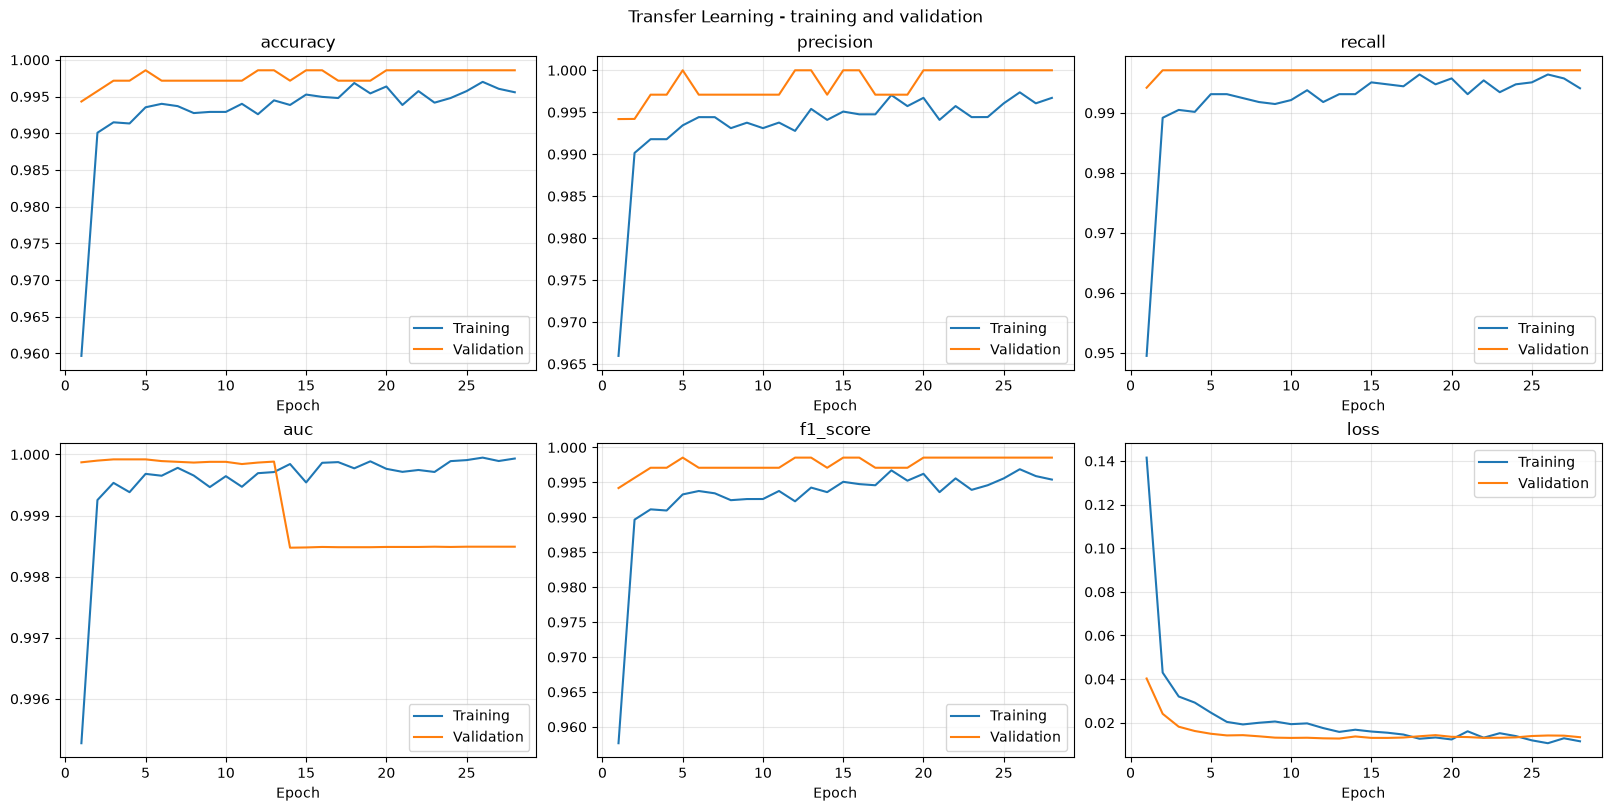

Transfer Learning - test metrics
{'loss': 0.022858714684844017, 'accuracy': 0.9929999709129333, 'precision': 0.9959758520126343, 'recall': 0.9900000095367432, 'auc': 0.998784601688385, 'f1_score': 0.9929788708686829}
class  precision  recall       f1  support
 cats   0.990060   0.996 0.993021     1000
 dogs   0.995976   0.990 0.992979     1000


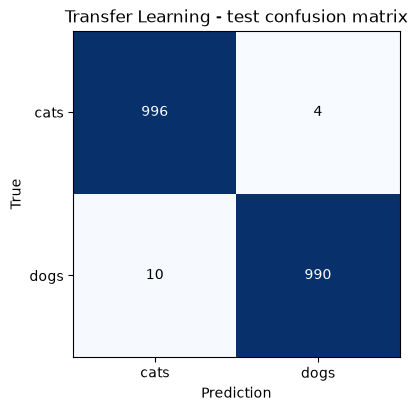

In [12]:
transfer_results = evaluate_and_save_stage(
    "transfer_learning", history_transfer, transfer_minutes,
    TRANSFER_MODEL_PATH, TRANSFER_WEIGHTS_PATH)


## Fine-tuning

Unfreeze the last 20 backbone layers, keep BatchNormalization frozen,
and train with Adam at 1e-5. EarlyStopping restores the weights with the
lowest validation loss within this phase. The transfer-learning model is already saved. Save and evaluate the fine-tuned model separately.


In [13]:
pretrained_model.trainable = True
for layer in pretrained_model.layers:
    layer.trainable = False
for layer in pretrained_model.layers[-FINE_TUNE_LAST_N:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True
compile_model(1e-5)
print("Trainable parameters:", sum(int(np.prod(v.shape)) for v in model.trainable_weights))


Trainable parameters: 1344049


In [14]:
start_time = time.perf_counter()
history_finetune = model.fit(
    train_data, epochs=FINETUNE_EPOCHS,
    validation_data=validation_data,
    callbacks=make_callbacks(FINETUNE_CHECKPOINT, patience=5))
finetune_minutes = (time.perf_counter() - start_time) / 60
print("Fine-tuning minutes:", finetune_minutes)


Epoch 1/50


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1789824461.828254    2218 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/cat_dog_EfficientNetB0_Top5Light_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


199/199 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.9942 - auc: 0.9997 - f1_score: 0.9939 - loss: 0.0174 - precision: 0.9951 - recall: 0.9928 - val_accuracy: 0.9986 - val_auc: 0.9985 - val_f1_score: 0.9985 - val_loss: 0.0124 - val_precision: 1.0000 - val_recall: 0.9971
Epoch 2/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9956 - auc: 0.9998 - f1_score: 0.9954 - loss: 0.0133 - precision: 0.9961 - recall: 0.9948 - val_accuracy: 0.9986 - val_auc: 0.9985 - val_f1_score: 0.9985 - val_loss: 0.0126 - val_precision: 1.0000 - val_recall: 0.9971
Epoch 3/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9943 - auc: 0.9997 - f1_score: 0.9941 - loss: 0.0160 - precision: 0.9941 - recall: 0.9941 - val_accuracy: 0.9972 - val_auc: 0.9985 - val_f1_score: 0.9971 - val_loss: 0.0131 - val_precision: 0.9971 - val_recall: 0.9971
Epoch 4/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.9964 - auc: 0.9998 - f1_score: 0.9962 - loss: 0.0111 - precision: 0.9967 - recall: 0.995

Saved model: /workspace/models/top10/cat_dog_EfficientNetB0_Top5Light/cat_dog_EfficientNetB0_Top5Light_fine_tuning.keras


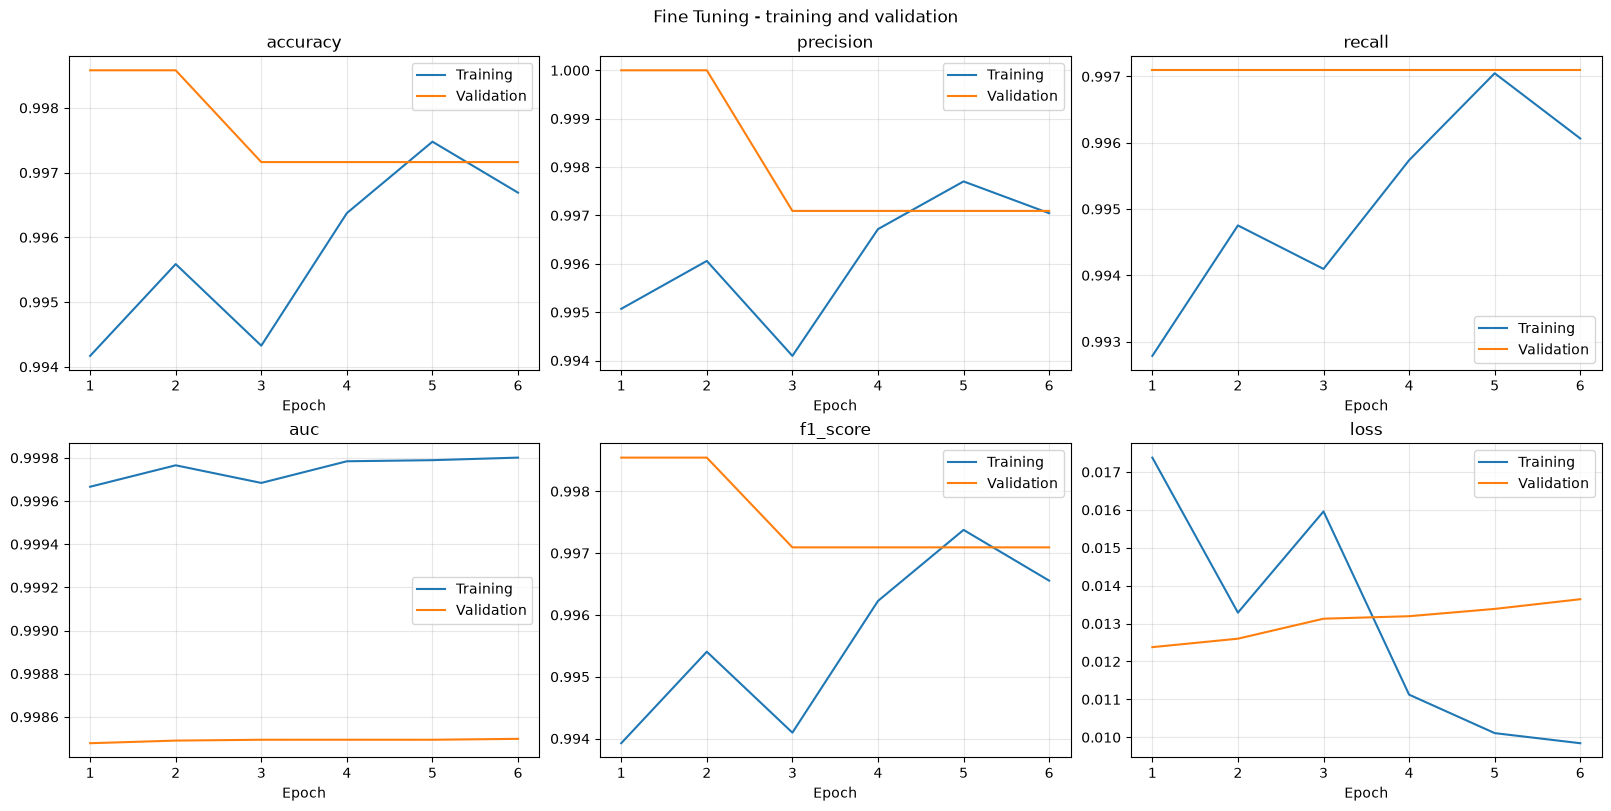

Fine Tuning - test metrics
{'loss': 0.021997937932610512, 'accuracy': 0.9925000071525574, 'precision': 0.9949748516082764, 'recall': 0.9900000095367432, 'auc': 0.9988014101982117, 'f1_score': 0.9924811124801636}
class  precision  recall       f1  support
 cats   0.990050   0.995 0.992519     1000
 dogs   0.994975   0.990 0.992481     1000


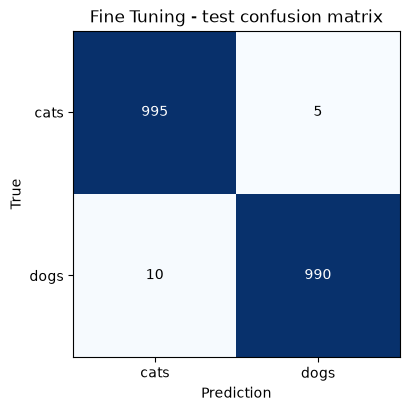

In [15]:
finetune_results = evaluate_and_save_stage(
    "fine_tuning", history_finetune, finetune_minutes,
    FINETUNE_MODEL_PATH, FINETUNE_WEIGHTS_PATH)


## Compare both phases

Compare test scores and the fine-tuning change in percentage points.
Both saved models remain available; choose which one to use.


Test metrics: positive change_pp means improvement, in percentage points.
                 transfer_learning  fine_tuning  change_pp
metric                                                    
accuracy                    0.9930       0.9925    -0.0500
precision                   0.9960       0.9950    -0.1001
recall                      0.9900       0.9900     0.0000
auc                         0.9988       0.9988     0.0017
f1_score                    0.9930       0.9925    -0.0498
macro_precision             0.9930       0.9925    -0.0505
macro_recall                0.9930       0.9925    -0.0500
macro_f1                    0.9930       0.9925    -0.0500
Test loss: 0.0229 -> 0.0220 (lower is better)


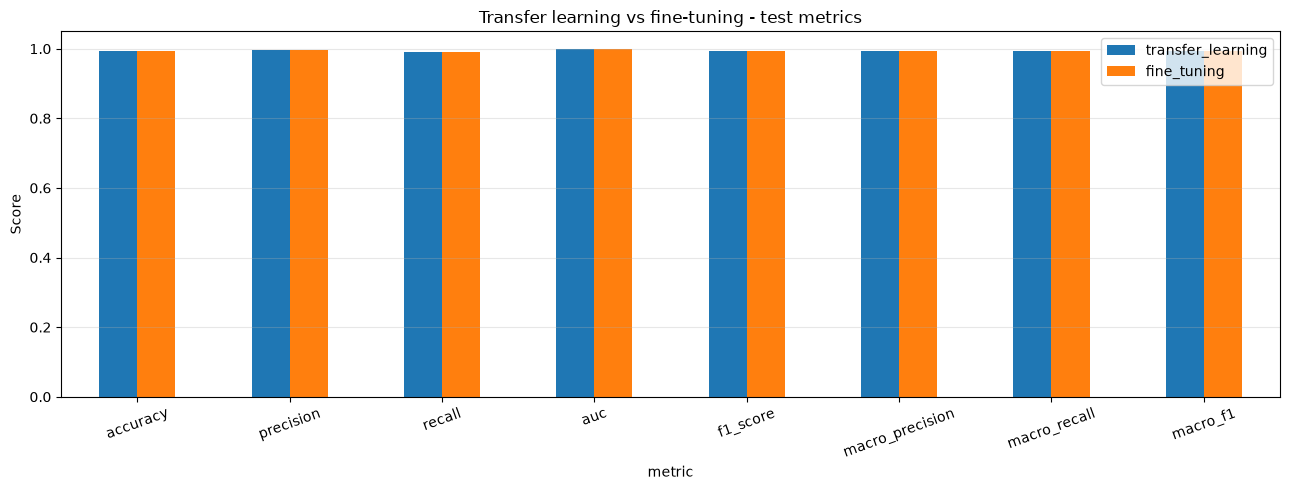

Transfer learning model: /workspace/models/top10/cat_dog_EfficientNetB0_Top5Light/cat_dog_EfficientNetB0_Top5Light_transfer_learning.keras
Fine-tuning model: /workspace/models/top10/cat_dog_EfficientNetB0_Top5Light/cat_dog_EfficientNetB0_Top5Light_fine_tuning.keras


In [16]:
metric_names = ["accuracy", "precision", "recall", "auc", "f1_score", "macro_precision", "macro_recall", "macro_f1"]
comparison = pd.DataFrame({
    "transfer_learning": [transfer_results[name] for name in metric_names],
    "fine_tuning": [finetune_results[name] for name in metric_names],
}, index=pd.Index(metric_names, name="metric"))
comparison["change_pp"] = 100 * (comparison["fine_tuning"] - comparison["transfer_learning"])
comparison.to_csv(RESULT_DIR / "stage_comparison.csv")
print("Test metrics: positive change_pp means improvement, in percentage points.")
print(comparison.to_string(float_format=lambda value: f"{value:.4f}"))
print(f"Test loss: {transfer_results['loss']:.4f} -> {finetune_results['loss']:.4f} (lower is better)")
ax = comparison[["transfer_learning", "fine_tuning"]].plot.bar(figsize=(13, 5), rot=20)
ax.set(title="Transfer learning vs fine-tuning - test metrics", ylabel="Score", ylim=(0, 1.05))
ax.grid(axis="y", alpha=0.3)
ax.figure.tight_layout()
ax.figure.savefig(RESULT_DIR / "stage_comparison.png", dpi=150)
plt.show()
print("Transfer learning model:", TRANSFER_MODEL_PATH)
print("Fine-tuning model:", FINETUNE_MODEL_PATH)


## Optional TFLite export

Set `EXPORT_TFLITE=True` to export a regular and a dynamically quantized model.
The inference graph keeps preprocessing and excludes random augmentation.

This optional export uses the fine-tuned model currently in memory.


In [21]:
if EXPORT_TFLITE:
    inference_inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3), name="rgb_image")
    x = inference_inputs
    # Preprocessing is included in the backbone.
    x = pretrained_model(x, training=False)
    x = model.get_layer("global_pool")(x)
    inference_outputs = model.get_layer("prediction")(x)
    inference_model = tf.keras.Model(inference_inputs, inference_outputs)
    sample = next(iter(test_data))[0][:1]
    np.testing.assert_allclose(model(sample, training=False).numpy(),
                               inference_model(sample, training=False).numpy(), atol=1e-6)
    for path, optimize in [(TFLITE_PATH, True), (OPTIMIZED_TFLITE_PATH, True)]:
        converter = tf.lite.TFLiteConverter.from_keras_model(inference_model)
        if optimize:
            converter.optimizations = [tf.lite.Optimize.DEFAULT]
        path.write_bytes(converter.convert())
        print(path.name, round(path.stat().st_size / 1024**2, 2), "MB")
else:
    print("TFLite disabled; set EXPORT_TFLITE=True to export.")


INFO:tensorflow:Assets written to: /tmp/tmplt8a6m0p/assets


INFO:tensorflow:Assets written to: /tmp/tmplt8a6m0p/assets


Saved artifact at '/tmp/tmplt8a6m0p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='rgb_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135604198163856: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135604198163088: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135619234887056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358905616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358905808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358904656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358905424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358904464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358904848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358904272: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

W0000 00:00:1789824894.364114    2218 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789824894.364151    2218 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


cat_dog_EfficientNetB0_Top5Light_fine_tuning.tflite 4.36 MB
INFO:tensorflow:Assets written to: /tmp/tmp9jgohi5s/assets


INFO:tensorflow:Assets written to: /tmp/tmp9jgohi5s/assets


Saved artifact at '/tmp/tmp9jgohi5s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='rgb_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135604198163856: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135604198163088: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  135619234887056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358905616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358905808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358904656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358905424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358904464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358904848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135606358904272: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

W0000 00:00:1789824902.123109    2218 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789824902.123140    2218 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


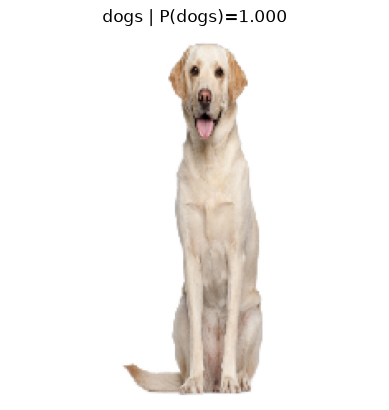

In [20]:
# The model is already in memory; in a new session load it with:
# model = tf.keras.models.load_model(FINETUNE_MODEL_PATH, compile=False)
# Use TRANSFER_MODEL_PATH instead to load the transfer-learning model.
# class_names = json.loads((MODEL_DIR / "labels.json").read_text())
image_path = PROJECT_ROOT / "dog.png"
if image_path.is_file():
    image = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    img = tf.keras.utils.img_to_array(image)
    probability = float(model(np.expand_dims(img, 0), training=False).numpy()[0, 0])
    label = class_names[int(probability > THRESHOLD)]
    plt.imshow(image)
    plt.title(f"{label} | P({class_names[1]})={probability:.3f}")
    plt.axis("off")
    plt.show()
else:
    print("Set image_path to test your own image.")
